In [ ]:
# %%  输入为呼吸信号、脉搏波信号、RR间期和经验特征
# modified at 20250424 在main_new_20250411.py的基础上加入了TFC预训练
# modified at 20250526 适应新数据格式
# modified at 20250612 采用整晚训练整晚验证
# modified at 20250624 加入金字塔输出和损失，纳入心跳信号，问卷损失
# modified at 20251028 实现阴性和阳性的分类，也就是从正常人群中检测出阳性样本

import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import os
import pickle
import random
import gc
from dpandataset import ZHEdataset
from dpanmodel_vis import DPANnet_Tiny_Transformer


# ---- 必要参数与设备设定 ----
device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
data_dir = '/data108/user_ww/Project/DepressionData/'
batch_size = 8
seg_len = 7200      # 片段时长（单位：秒）
dynamic = True
mc_flag = False

# 数据集与索引
dataset = ZHEdataset(data_dir, seg_len, True, mc_flag, device, dynamic)
dataset_w = ZHEdataset(data_dir, seg_len, False, mc_flag, device, dynamic)
train_index, valid_index, num_list, s_num_list = dataset.split(fold=0, batch_size=batch_size)
d_valid = DataLoader(Subset(dataset_w, valid_index), batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

# n_classes = 6  # Wake REM N1 N2 N3 离床
# n_hidden = 128
# n_layers = 2
# n_fea = 132
# model = DPANnet_Tiny_Transformer(nhid=n_hidden, nlayers=n_layers, nstage=n_classes, ndisea=dataset.n_disea, D=2, flag=mc_flag, nfea=n_fea).to(device)


n_classes = 6  # Wake REM N1 N2 N3 离床
n_hidden = 128
n_layers = 2
n_fea = dataset.n_fea
fea_used = False
model = DPANnet_Tiny_Transformer(nhid=n_hidden, nlayers=n_layers, nstage=n_classes, ndisea=dataset.n_disea, D=2, flag=mc_flag, nfea=n_fea, fea_used=fea_used).to(device)


# ---- 加载特定epoch的权重 ----
checkpoint_path = '/data108/user_ww/Project/Depression1028/checkpoints/2025-11-15-17-30-17/last.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model"], strict=True)
model.eval()

print(f"Loaded weights from {checkpoint_path}")





Loaded weights from /data108/user_ww/Project/Depression1028/checkpoints/2025-11-15-17-30-17/last.pth


可视化: vit_fuse.transformer.layers.0.0.to_qkv.weight


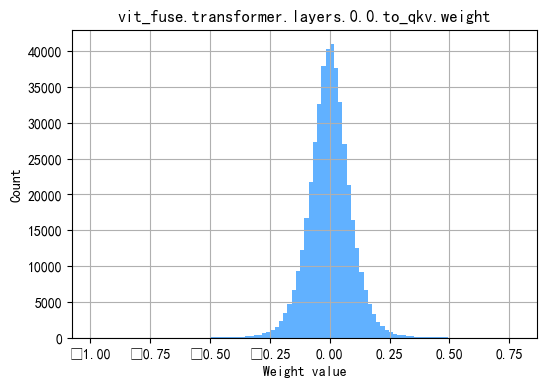

可视化: vit_fuse.transformer.layers.0.1.net.0.weight


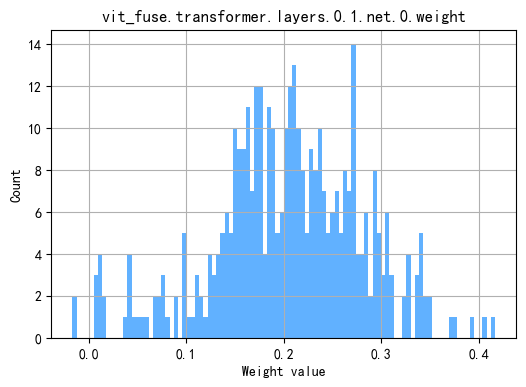

权重分布可视化图片已在notebook中显示。


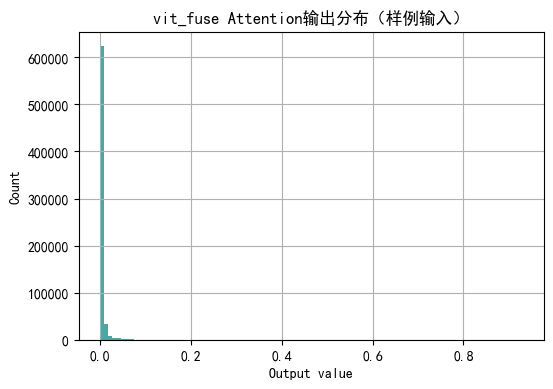

vit_fuse Attention层输出分布（样例输入）已在notebook中显示。


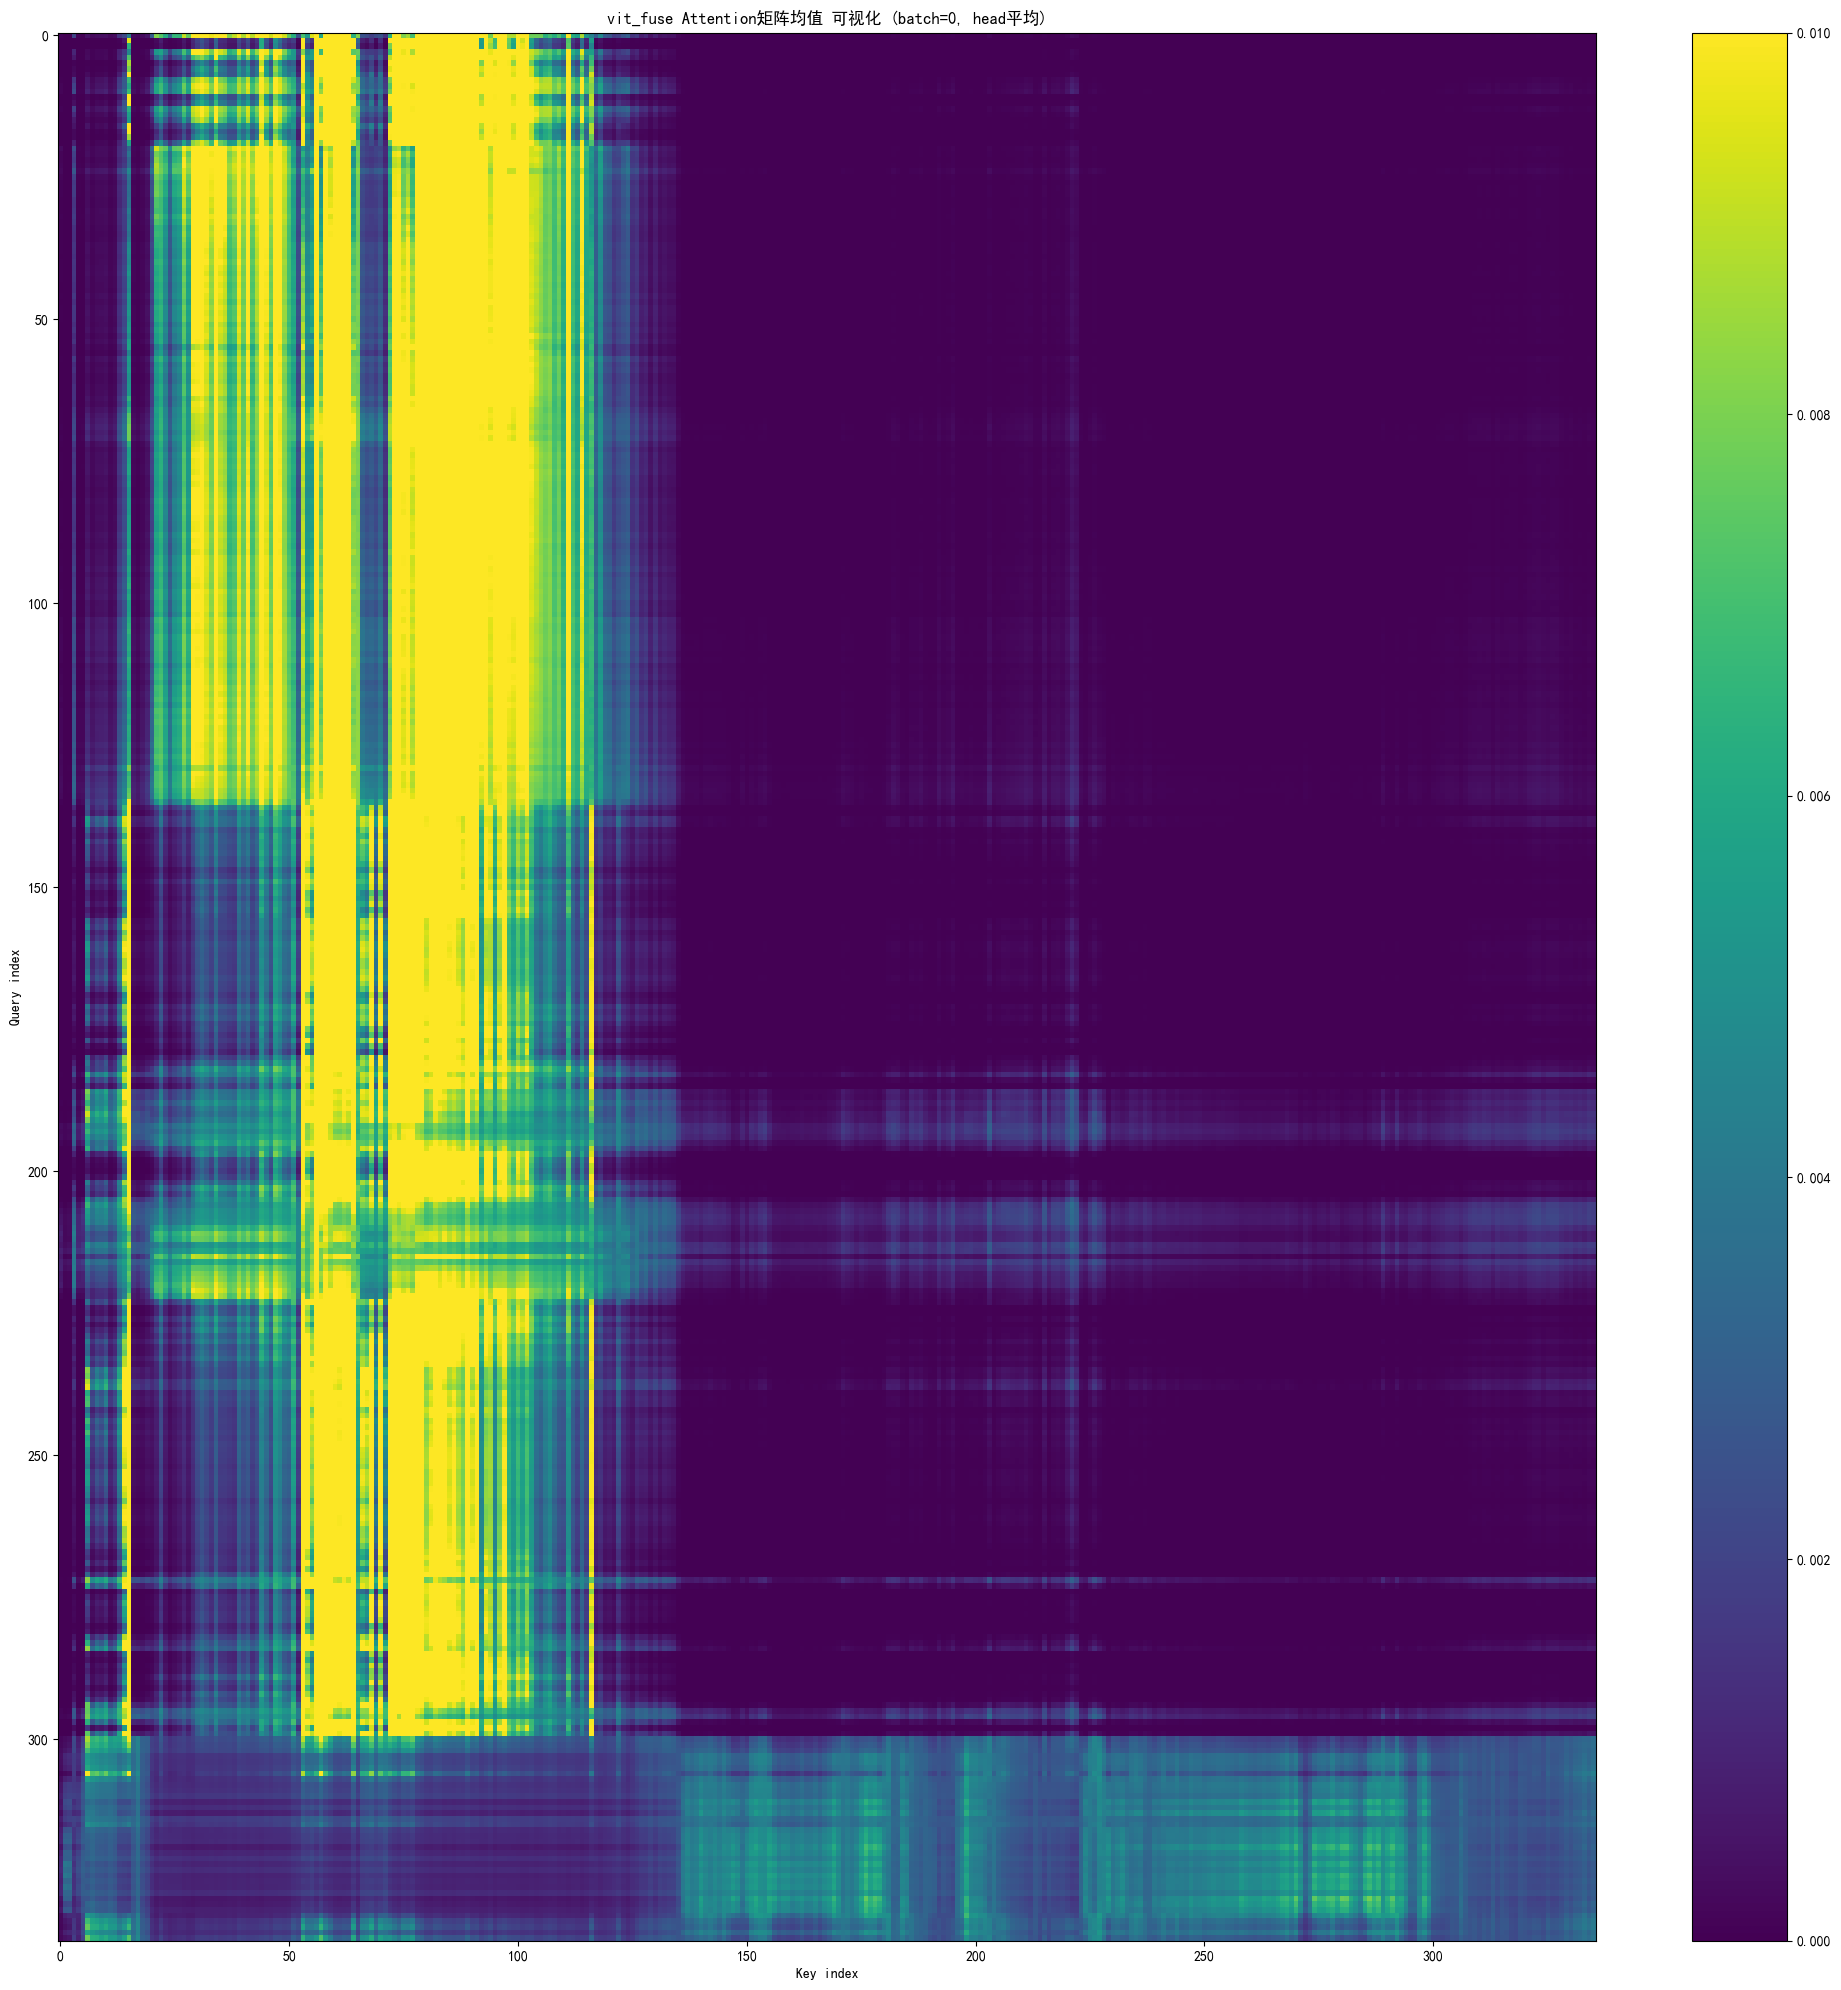

vit_fuse Attention矩阵（batch=0, 所有head均值）已在notebook中显示。


/tmp/ipykernel_3171273/3590071497.py:206: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  plt.tight_layout()
/data108/user_ww/miniconda3/envs/pytorch/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


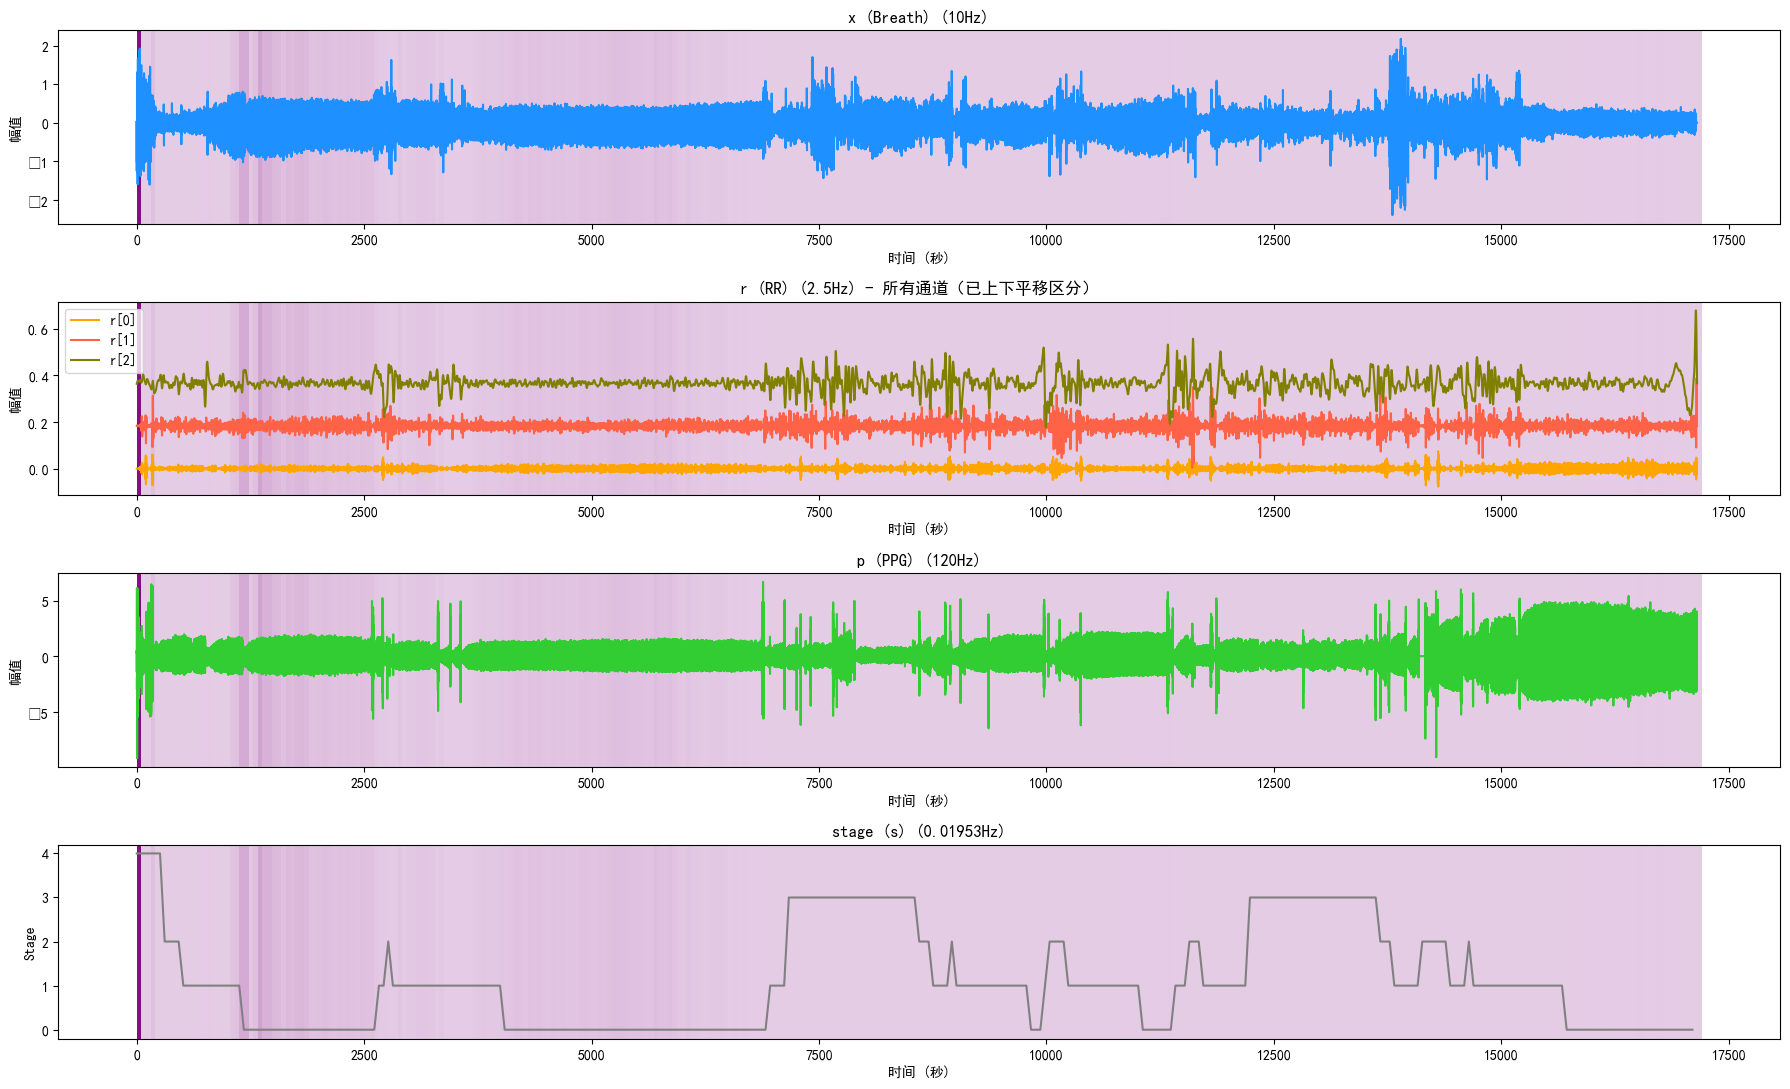

x, r[0], r[1], r[2], p, s已分别绘制在独立子图，r的三个分量已上下平移区分，attn_token0 透明度分布根据采样率差异已合理映射于各信号的时间轴背景。
x长度: 171520 采样率:10Hz
r长度: 42880 采样率:2.5Hz
p长度: 2058240 采样率:120Hz
s长度: 335 采样率:0.01953Hz
attn_token0长度: 336 采样率:0.01953Hz
模型vit_fuse关键层注意力/激活分布分析完成。


In [59]:
# ---- 网络关键层权重分布可视化 ----

def plot_weight_distribution(param_tensor, title="权重分布", bins=100):
    param_np = param_tensor.detach().cpu().numpy().flatten()
    plt.figure(figsize=(6,4))
    plt.hist(param_np, bins=bins, alpha=0.7, color='dodgerblue')
    plt.xlabel('Weight value')
    plt.ylabel('Count')
    plt.title(title)
    plt.grid(True)
    plt.show()
    plt.close()

# 选择关注的关键层，可以按需修改
# 观察vit_fuse模块的关键层权重
key_layers = {
    "vit_fuse.transformer.layers.0.0.to_qkv.weight": model.vit_fuse.transformer.layers[0][0].to_qkv.weight,
    "vit_fuse.transformer.layers.0.1.net.0.weight": model.vit_fuse.transformer.layers[0][1].net[0].weight
}

for key, param in key_layers.items():
    print(f"可视化: {key}")
    plot_weight_distribution(param, title=key)

print(f"权重分布可视化图片已在notebook中显示。")

# ---- 可选：结合具体数据输入分析vit_fuse注意力分布 ----

# 从验证集取1个batch的输入（整晚数据）
inputs = d_valid.dataset.__getitem__(0)
x, r, p, f, s, y, zr, mask_attn = [xx.to(device).unsqueeze(dim=0) for xx in inputs]

s = s[:,::32]
s = s[:,::4]
mask_attn = mask_attn[:,::48]
mask_attn = mask_attn[:,::32]
mask_attn = mask_attn[:,::4]
# 前向传播至vit_fuse模块，分析其注意力输出
# 下面 hook vit_fuse.transformer.layers[0][0] (即第1层Attention)的输出

def get_attn_output_hook(outputs_list):
    def fn(module, input, output):
        outputs_list.append(output[1].detach().cpu())
    return fn

vit_attn_outputs = []
vit_attn_module = model.vit_fuse.transformer.layers[3][0]  # vit_fuse transformer第0层注意力模块
hook_handle = vit_attn_module.register_forward_hook(get_attn_output_hook(vit_attn_outputs))

with torch.no_grad():
    # 为获取vit_fuse attention的真实输入，需走模型前向部分代码。一般模型forward会先对(x,r,p,...)编码，提取特征后送入vit_fuse
    # 如只关注vit_fuse的输入，请确保调用model时会走到vit_fuse.transformer的forward
    # 完整推理
    model.eval()
    _ = model(x, r, p, f, s, mask_attn) 

hook_handle.remove()

if vit_attn_outputs:
    # 让matplotlib优先使用支持中文的字体
    plt.rcParams['font.sans-serif'] = ['SimHei']  # 增加这一行以显示中文
    attn = vit_attn_outputs[0]  # shape: (batch, head, seq, seq)
    # 展平画统计分布
    attn_np = attn.flatten().numpy()
    plt.figure(figsize=(6,4))
    plt.hist(attn_np, bins=100, alpha=0.7, color='teal')
    plt.title("vit_fuse Attention输出分布（样例输入）")
    plt.xlabel("Output value")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()
    plt.close()
    print("vit_fuse Attention层输出分布（样例输入）已在notebook中显示。")

    # 可视化所有头的平均注意力矩阵
    # attn shape: (batch, head, seq, seq)
    attn_mean = attn[0][0].numpy()  # 对head取平均, shape (seq, seq)
    plt.figure(figsize=(20,20))
    im = plt.imshow(attn_mean, aspect='auto', cmap='viridis', vmin=0, vmax=0.01)
    plt.colorbar(im)
    plt.title("vit_fuse Attention矩阵均值 可视化 (batch=0, head平均)")
    plt.xlabel("Key index")
    plt.ylabel("Query index")
    plt.tight_layout()
    plt.show()
    plt.close()
    print("vit_fuse Attention矩阵（batch=0, 所有head均值）已在notebook中显示。")

    # 合并绘图，将 attn_token0 透明度覆盖在每条信号的背景上，并区分r在dim=1的三个分量，分别上下平移以便区分
    # 各采样率：x: 10Hz, r:2.5Hz, p:120Hz, s/attn_token0: 2.5/128 Hz

    attn_token0 = attn[0].mean(dim=0)[0].numpy()  # (seq,)
    seg_len = x.shape[-1]

    # 获取数据
    x_plot = x[0, 0, :].detach().cpu().numpy()
    # r_plot = r[0, 0, :].detach().cpu().numpy()
    # r shape: (batch, chan(3), sample)
    r_plot_all = [r[0, i, :].detach().cpu().numpy() for i in range(r.shape[1])]
    p_plot = p[0, 0, :].detach().cpu().numpy()
    s_plot = s[0, :].detach().cpu().numpy() if len(s.shape) == 2 else s[0].detach().cpu().numpy()

    # 计算长度
    len_x = x_plot.shape[0]
    len_r = r_plot_all[0].shape[0]
    len_p = p_plot.shape[0]
    len_s = s_plot.shape[0]
    len_attn = attn_token0.shape[0]

    # 不同信号采样率
    rate_x = 10.0
    rate_r = 2.5
    rate_p = 120.0
    rate_s = 2.5 / 128
    sample_rate_s = rate_s

    t_x = np.arange(len_x) / rate_x
    t_r = np.arange(len_r) / rate_r
    t_p = np.arange(len_p) / rate_p
    t_s = np.arange(len_s) / sample_rate_s
    t_attn = np.arange(len_attn) / sample_rate_s

    # Min-max归一到[a,b]
    def norm_to_alpha(arr, a=0.2, b=1.0):
        arr_std = (arr - arr.min()) / (arr.max() - arr.min() + 1e-7)
        return arr_std * (b - a) + a

    attn_alpha = norm_to_alpha(attn_token0, a=0.2, b=0.95)

    # 通用: 对信号的采样点，反查其所处整段的attn/bin
    def attn_alpha_for_timegrid(t_grid, t_attn_grid, attn_alpha_arr):
        # t_grid: 该信号的采样点时间轴
        # t_attn_grid: attn的片段边界时间（必须升序且等间隔）
        # 返回：每个采样时间点对应的attn_alpha，采用最近左区间原则
        # 若t_grid超范围，则端点外均给第一个/最后一个alpha
        idxs = np.searchsorted(t_attn_grid, t_grid, side='right') - 1
        idxs[idxs < 0] = 0
        idxs[idxs >= len(attn_alpha_arr)] = len(attn_alpha_arr) - 1
        return attn_alpha_arr[idxs]

    fig, axs = plt.subplots(4, 1, figsize=(18, 11), sharex=False)
    plt.subplots_adjust(hspace=0.5)

    # 绘制 x
    axs[0].plot(t_x, x_plot, color='dodgerblue', zorder=2)
    axs[0].set_title('x (Breath) (10Hz)')
    axs[0].set_xlabel('时间 (秒)')
    axs[0].set_ylabel('幅值')
    ymin, ymax = axs[0].get_ylim()
    for j in range(len_attn):
        x1 = t_attn[j]
        if j == len_attn - 1:
            x2 = t_attn[j] + (t_attn[j] - t_attn[j-1] if j > 0 else sample_rate_s)
        else:
            x2 = t_attn[j+1]
        axs[0].axvspan(x1, x2, ymin=0, ymax=1, facecolor='purple', alpha=attn_alpha[j], zorder=1, linewidth=0)

    # 绘制 r 的每个分量并分别平移
    colors_r = ['orange', 'tomato', 'olive']
    shifts = [0.0, 1.2 * np.ptp(r_plot_all[0]), 2.4 * np.ptp(r_plot_all[0])]  # 平移幅度互不重叠
    for i in range(3):
        r_sig = r_plot_all[i]
        t_r_plot = t_r
        axs[1].plot(t_r_plot, r_sig + shifts[i], color=colors_r[i], zorder=2, label=f'r[{i}]')
    axs[1].set_title('r (RR) (2.5Hz) - 所有通道（已上下平移区分）')
    axs[1].set_xlabel('时间 (秒)')
    axs[1].set_ylabel('幅值')
    axs[1].legend()
    ymin, ymax = axs[1].get_ylim()
    for j in range(len_attn):
        x1 = t_attn[j]
        if j == len_attn - 1:
            x2 = t_attn[j] + (t_attn[j] - t_attn[j-1] if j > 0 else sample_rate_s)
        else:
            x2 = t_attn[j+1]
        axs[1].axvspan(x1, x2, ymin=0, ymax=1, facecolor='purple', alpha=attn_alpha[j], zorder=1, linewidth=0)

    # 绘制p
    axs[2].plot(t_p, p_plot, color='limegreen', zorder=2)
    axs[2].set_title('p (PPG) (120Hz)')
    axs[2].set_xlabel('时间 (秒)')
    axs[2].set_ylabel('幅值')
    ymin, ymax = axs[2].get_ylim()
    for j in range(len_attn):
        x1 = t_attn[j]
        if j == len_attn - 1:
            x2 = t_attn[j] + (t_attn[j] - t_attn[j-1] if j > 0 else sample_rate_s)
        else:
            x2 = t_attn[j+1]
        axs[2].axvspan(x1, x2, ymin=0, ymax=1, facecolor='purple', alpha=attn_alpha[j], zorder=1, linewidth=0)

    # 绘制s
    axs[3].plot(t_s, s_plot, color='grey', zorder=2)
    axs[3].set_title(f'stage (s) ({sample_rate_s:.5f}Hz)')
    axs[3].set_xlabel('时间 (秒)')
    axs[3].set_ylabel('Stage')
    ymin, ymax = axs[3].get_ylim()
    for j in range(len_attn):
        x1 = t_attn[j]
        if j == len_attn - 1:
            x2 = t_attn[j] + (t_attn[j] - t_attn[j-1] if j > 0 else sample_rate_s)
        else:
            x2 = t_attn[j+1]
        axs[3].axvspan(x1, x2, ymin=0, ymax=1, facecolor='purple', alpha=attn_alpha[j], zorder=1, linewidth=0)

    plt.tight_layout()
    plt.show()
    plt.close()

    print("x, r[0], r[1], r[2], p, s已分别绘制在独立子图，r的三个分量已上下平移区分，attn_token0 透明度分布根据采样率差异已合理映射于各信号的时间轴背景。")
    print(
        f"x长度: {len_x} 采样率:10Hz\n"
        f"r长度: {len_r} 采样率:2.5Hz\n"
        f"p长度: {len_p} 采样率:120Hz\n"
        f"s长度: {len_s} 采样率:{sample_rate_s:.5f}Hz\n"
        f"attn_token0长度: {len_attn} 采样率:{sample_rate_s:.5f}Hz"
    )

# 你可以按需hook vit_fuse的不同层/不同head，更细致可视化
# 总结：
print("模型vit_fuse关键层注意力/激活分布分析完成。")



======= Fold 0 =======
Loaded weights from /data108/user_ww/Project/Depression1028/checkpoints/2025-11-19-15-06-23/last.pth


100%|██████████| 297/297 [00:36<00:00,  8.05it/s]


验证集整体准确率: 55.22%
Kappa系数: 0.3330
混淆矩阵：
[[101  20  34   0]
 [  2  13  25   4]
 [  8  12  50   1]
 [  3   9  15   0]]


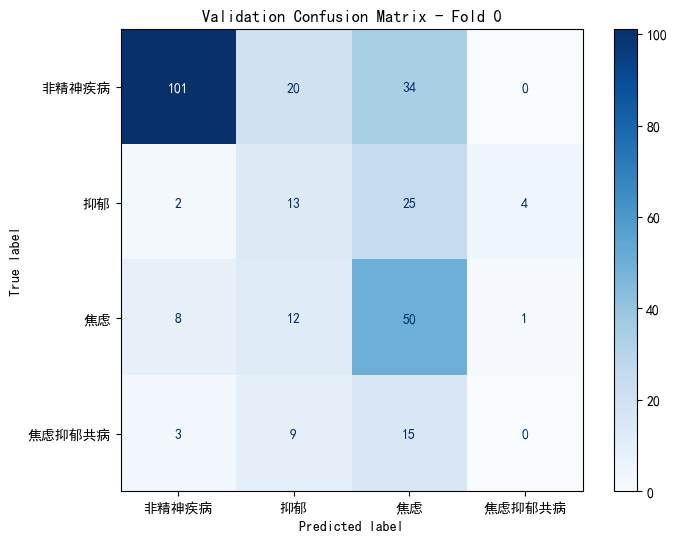

二分类(非精神疾病 vs 精神疾病)准确率: 77.44%
二分类(非精神疾病 vs 精神疾病)Kappa系数: 0.5534
二分类（非精神疾病 vs 精神疾病）混淆矩阵：
[[101  54]
 [ 13 129]]


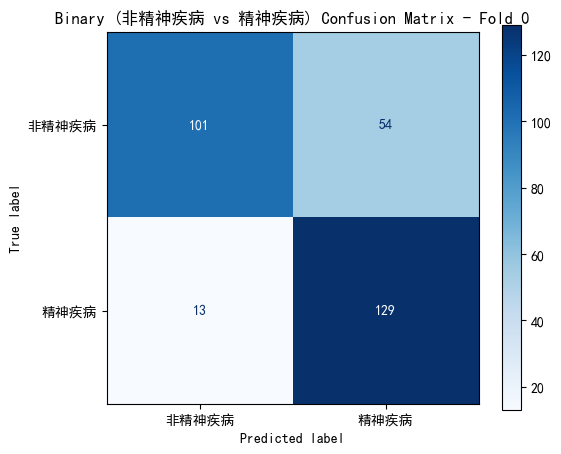


======= Fold 1 =======
Loaded weights from /data108/user_ww/Project/Depression1028/checkpoints/2025-11-20-00-53-58/last.pth


100%|██████████| 282/282 [00:34<00:00,  8.08it/s]


验证集整体准确率: 58.87%
Kappa系数: 0.3569
混淆矩阵：
[[118  13  16   7]
 [  4  21   9   6]
 [ 14  18  25  11]
 [  7   4   7   2]]


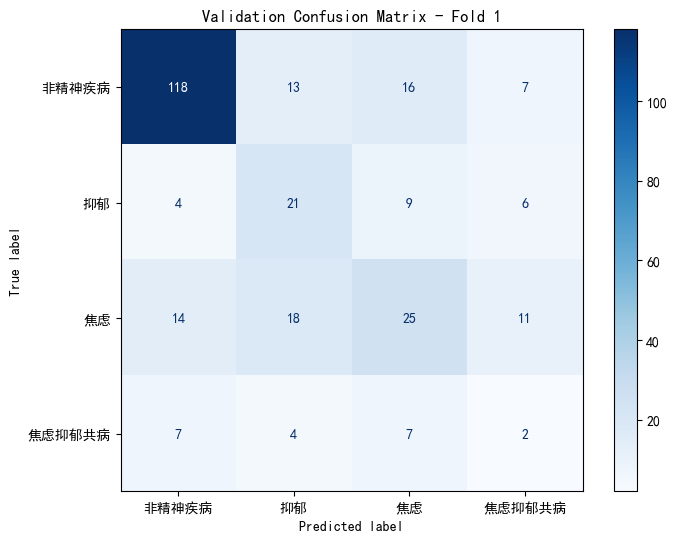

二分类(非精神疾病 vs 精神疾病)准确率: 78.37%
二分类(非精神疾病 vs 精神疾病)Kappa系数: 0.5668
二分类（非精神疾病 vs 精神疾病）混淆矩阵：
[[118  36]
 [ 25 103]]


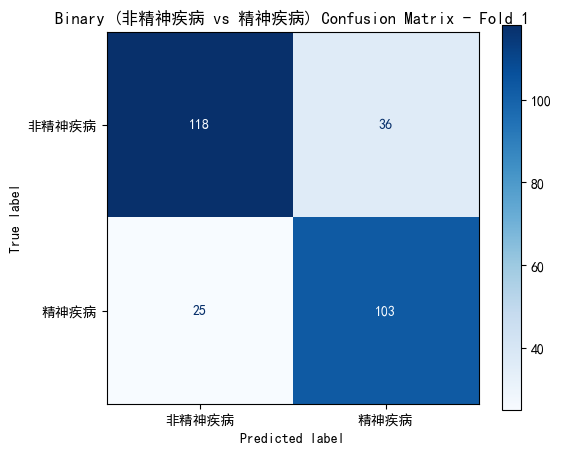


======= Fold 2 =======
Loaded weights from /data108/user_ww/Project/Depression1028/checkpoints/2025-11-20-00-54-51/last.pth


100%|██████████| 302/302 [00:35<00:00,  8.39it/s]


验证集整体准确率: 53.31%
Kappa系数: 0.2997
混淆矩阵：
[[105  13  28   9]
 [  9  23  10   5]
 [ 16  20  32  10]
 [  4  11   6   1]]


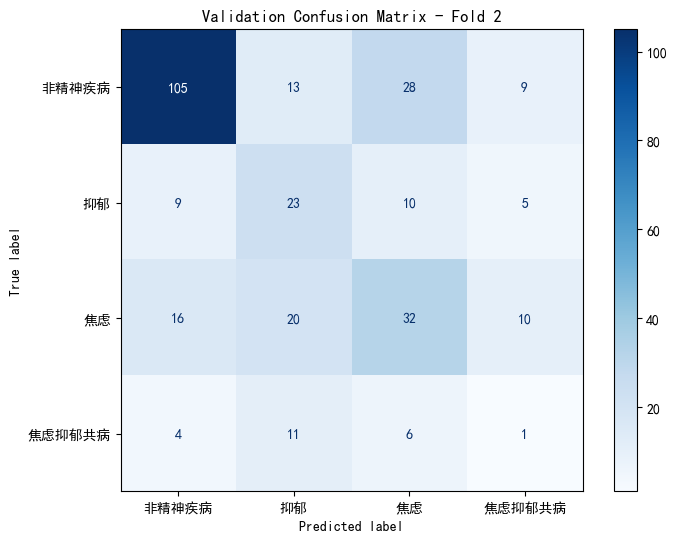

二分类(非精神疾病 vs 精神疾病)准确率: 73.84%
二分类(非精神疾病 vs 精神疾病)Kappa系数: 0.4784
二分类（非精神疾病 vs 精神疾病）混淆矩阵：
[[105  50]
 [ 29 118]]


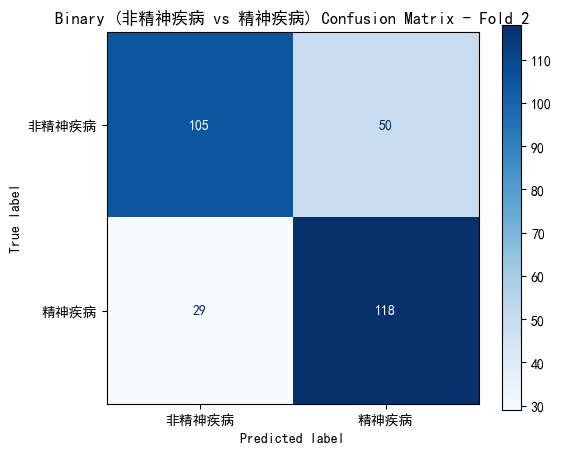


======= Fold 3 =======
Loaded weights from /data108/user_ww/Project/Depression1028/checkpoints/2025-11-20-00-55-05/last.pth


100%|██████████| 293/293 [00:35<00:00,  8.28it/s]


验证集整体准确率: 51.19%
Kappa系数: 0.2318
混淆矩阵：
[[115  20  18   2]
 [ 15  17   4   2]
 [ 24  28  18   1]
 [  5  15   9   0]]


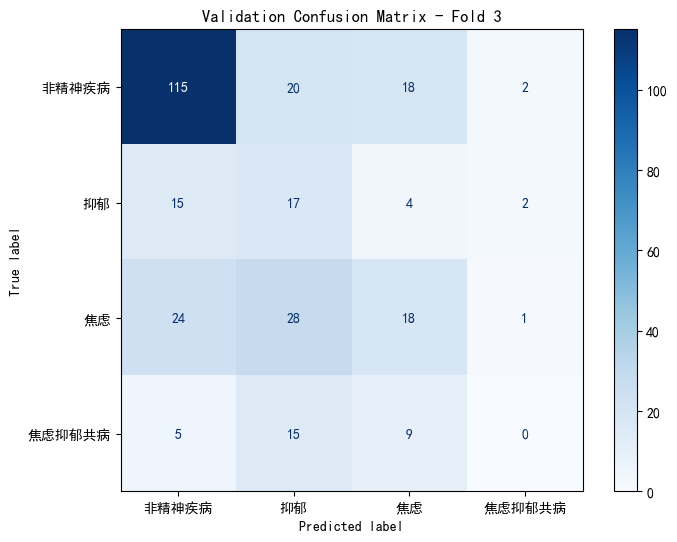

二分类(非精神疾病 vs 精神疾病)准确率: 71.33%
二分类(非精神疾病 vs 精神疾病)Kappa系数: 0.4238
二分类（非精神疾病 vs 精神疾病）混淆矩阵：
[[115  40]
 [ 44  94]]


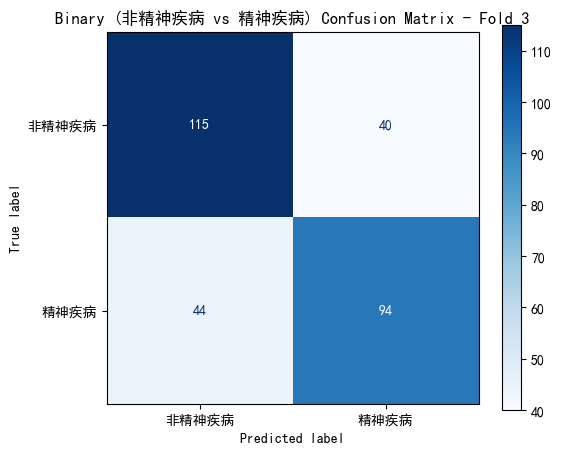


====== 汇总4折验证集结果（仅前4类）======
全部验证集整体准确率: 54.60%
全部Kappa系数: 0.3050
全部验证集混淆矩阵：
[[439  66  96  18]
 [ 30  74  48  17]
 [ 62  78 125  23]
 [ 19  39  37   3]]


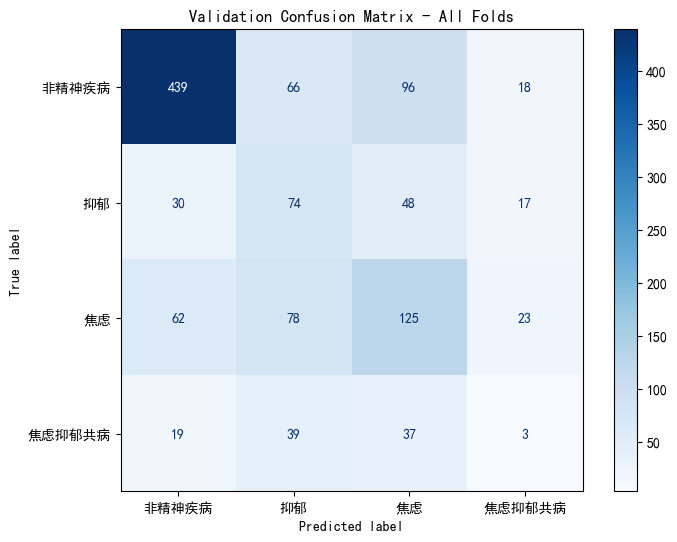

全部二分类(非精神疾病 vs 精神疾病)准确率: 75.21%
全部二分类(非精神疾病 vs 精神疾病)Kappa系数: 0.5060
全部二分类（非精神疾病 vs 精神疾病）混淆矩阵：
[[439 180]
 [111 444]]


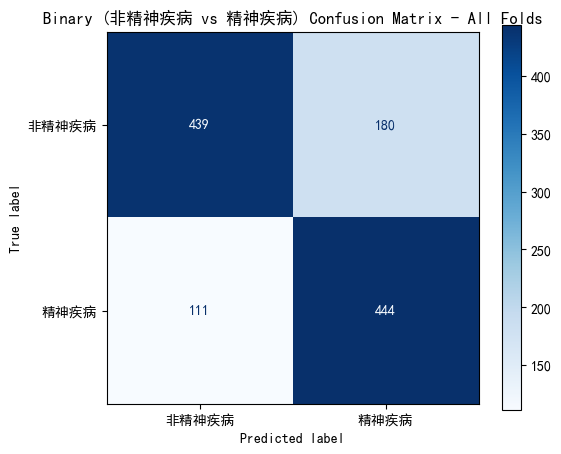


每折统计：
Fold0: acc=55.22%  kappa=0.3330  二分类acc=77.44%  二分类kappa=0.5534
Fold1: acc=58.87%  kappa=0.3569  二分类acc=78.37%  二分类kappa=0.5668
Fold2: acc=53.31%  kappa=0.2997  二分类acc=73.84%  二分类kappa=0.4784
Fold3: acc=51.19%  kappa=0.2318  二分类acc=71.33%  二分类kappa=0.4238


In [5]:
# 统计模型在验证集上的准确率、绘制混淆矩阵、计算kappa、二分类(0/精神疾病)准确率和kappa
# 注: 这里的y_pred和y_true不再是睡眠stage预测结果，而是模型第二个输出logit_dis的预测类别

from tqdm import tqdm
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score, ConfusionMatrixDisplay

# 设置matplotlib可显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号

import torch.nn as nn
from torch.utils.data import DataLoader, Subset
import os
import pickle
import random
import gc
from dpandataset import ZHEdataset
from dpanmodel_vis import DPANnet_Tiny_Transformer

# === 类别与疾病的对应关系 ===
# { '非精神疾病': 0, '抑郁': 1, '焦虑': 2, '焦虑抑郁共病': 3 }
disease_label_map = {
    0: '非精神疾病',
    1: '抑郁',
    2: '焦虑',
    3: '焦虑抑郁共病'
}

# ---- 必要参数与设备设定 ----
device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
data_dir = '/data108/user_ww/Project/DepressionData/'
batch_size = 8
seg_len = 7200      # 片段时长（单位：秒）
dynamic = True
mc_flag = False
# model_name = ['2025-11-15-17-30-17', '2025-11-17-20-14-59', '2025-11-17-20-30-55', '2025-11-17-20-42-03']
model_name = ['2025-11-19-15-06-23', '2025-11-20-00-53-58', '2025-11-20-00-54-51', '2025-11-20-00-55-05']
fold = 0

# 遍历fold从0到3，统计每折结果和总的结果

all_y_true = []
all_y_pred = []
all_y_true_bin = []
all_y_pred_bin = []
fold_acc = []
fold_kappa = []
fold_acc_bin = []
fold_kappa_bin = []

for fold in range(4):
    print(f"\n======= Fold {fold} =======")
    # 数据集与索引
    dataset = ZHEdataset(data_dir, seg_len, True, mc_flag, device, dynamic)
    dataset_w = ZHEdataset(data_dir, seg_len, False, mc_flag, device, dynamic)
    train_index, valid_index, num_list, s_num_list = dataset.split(fold=fold, batch_size=batch_size)
    d_valid = DataLoader(Subset(dataset_w, valid_index), batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

    n_classes = 6  # Wake REM N1 N2 N3 离床
    n_hidden = 128
    n_layers = 2
    n_fea = dataset.n_fea
    fea_used = True
    model = DPANnet_Tiny_Transformer(nhid=n_hidden, nlayers=n_layers, nstage=n_classes, ndisea=dataset.n_disea, D=2, flag=mc_flag, nfea=n_fea, fea_used=fea_used).to(device)

    # ---- 加载特定epoch的权重 ----
    checkpoint_path = f'/data108/user_ww/Project/Depression1028/checkpoints/{model_name[fold]}/last.pth'
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model"], strict=True)
    model.eval()

    print(f"Loaded weights from {checkpoint_path}")

    correct = 0
    total = 0

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, r, p, f, s, y, zr, mask_attn in tqdm(d_valid):
            x = x.to(device)
            r = r.to(device)
            p = p.to(device)
            f = f.to(device)
            s = s.to(device)
            y = y.to(device)
            mask_attn = mask_attn.to(device)
            # zr无用，直接不送入模型

            s = s[:,::32]
            s = s[:,::4]
            mask_attn = mask_attn[:,::48]
            mask_attn = mask_attn[:,::32]
            mask_attn = mask_attn[:,::4]

            _, logit_dis, *_ = model(x, r, p, f, s, mask_attn)
            # logit_dis: (batch, n_disea)，y: (batch, )，通常是多分类 depression/anxiety
            pred_cls = logit_dis.argmax(dim=1)  # (batch,)
            target_cls = y.reshape(-1)  # (batch,)

            correct += (pred_cls == target_cls).sum().item()
            total += target_cls.numel()
            y_pred.append(pred_cls.cpu().numpy())
            y_true.append(target_cls.cpu().numpy())

    # 拼接成一维
    y_pred = np.concatenate(y_pred)
    y_true = np.concatenate(y_true)
    all_y_true.append(y_true)
    all_y_pred.append(y_pred)

    acc = correct / total * 100
    fold_acc.append(acc)
    print(f"验证集整体准确率: {acc:.2f}%")

    # 混淆矩阵和kappa
    # 只用前4个类别分析（即0:非精神疾病, 1:抑郁, 2:焦虑, 3:焦虑抑郁共病），多余类别不计入
    y_true_explicit = np.copy(y_true)
    y_pred_explicit = np.copy(y_pred)
    mask_valid = (y_true_explicit <= 3)
    y_true_explicit = y_true_explicit[mask_valid]
    y_pred_explicit = y_pred_explicit[mask_valid]
    cm = confusion_matrix(y_true_explicit, y_pred_explicit, labels=[0,1,2,3])
    kappa = cohen_kappa_score(y_true_explicit, y_pred_explicit, labels=[0,1,2,3])
    fold_kappa.append(kappa)
    print(f"Kappa系数: {kappa:.4f}")
    print("混淆矩阵：")
    print(cm)

    # 绘制多分类混淆矩阵，标签用疾病名称
    fig, ax = plt.subplots(figsize=(8,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[
        disease_label_map[0], disease_label_map[1], disease_label_map[2], disease_label_map[3]
    ])
    disp.plot(ax=ax, cmap='Blues', values_format="d")
    plt.title(f"Validation Confusion Matrix - Fold {fold}")
    plt.show()
    plt.close()

    # 只区分类别0和精神疾病类别（其余1/2/3）的准确率和kappa
    # 类别0: '非精神疾病'，其他（1/2/3）: 精神疾病
    y_true_bin = (y_true <= 0).astype(int)  # 0 (非精神疾病) -> 1，精神疾病->0
    y_pred_bin = (y_pred <= 0).astype(int)
    # 转换为 0:精神疾病, 1:非精神疾病, 为了显示美观下面会反转
    all_y_true_bin.append(y_true_bin)
    all_y_pred_bin.append(y_pred_bin)
    acc_bin = (y_true_bin == y_pred_bin).sum() / len(y_true_bin) * 100
    fold_acc_bin.append(acc_bin)
    kappa_bin = cohen_kappa_score(y_true_bin, y_pred_bin)
    fold_kappa_bin.append(kappa_bin)
    print(f"二分类(非精神疾病 vs 精神疾病)准确率: {acc_bin:.2f}%")
    print(f"二分类(非精神疾病 vs 精神疾病)Kappa系数: {kappa_bin:.4f}")

    # 画二分类混淆矩阵
    cm_bin = confusion_matrix(y_true_bin, y_pred_bin, labels=[1,0])
    print("二分类（非精神疾病 vs 精神疾病）混淆矩阵：")
    print(cm_bin)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=["非精神疾病", "精神疾病"])
    disp_bin.plot(ax=ax, cmap='Blues', values_format="d")
    plt.title(f"Binary (非精神疾病 vs 精神疾病) Confusion Matrix - Fold {fold}")
    plt.show()
    plt.close()


# 汇总所有fold
all_y_true = np.concatenate(all_y_true)
all_y_pred = np.concatenate(all_y_pred)
all_y_true_bin = np.concatenate(all_y_true_bin)
all_y_pred_bin = np.concatenate(all_y_pred_bin)

# 多分类统计只看前4类
all_y_true_explicit = all_y_true[all_y_true <= 3]
all_y_pred_explicit = all_y_pred[all_y_true <= 3]
acc = (all_y_true_explicit == all_y_pred_explicit).sum() / len(all_y_true_explicit) * 100
kappa = cohen_kappa_score(all_y_true_explicit, all_y_pred_explicit, labels=[0,1,2,3])
print("\n====== 汇总4折验证集结果（仅前4类）======")
print(f"全部验证集整体准确率: {acc:.2f}%")
print(f"全部Kappa系数: {kappa:.4f}")

cm = confusion_matrix(all_y_true_explicit, all_y_pred_explicit, labels=[0,1,2,3])
print("全部验证集混淆矩阵：")
print(cm)
fig, ax = plt.subplots(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[
    disease_label_map[0], disease_label_map[1], disease_label_map[2], disease_label_map[3]
])
disp.plot(ax=ax, cmap='Blues', values_format="d")
plt.title("Validation Confusion Matrix - All Folds")
plt.show()
plt.close()

# 二分类（非精神疾病 vs 精神疾病）
acc_bin = (all_y_true_bin == all_y_pred_bin).sum() / len(all_y_true_bin) * 100
kappa_bin = cohen_kappa_score(all_y_true_bin, all_y_pred_bin)
print(f"全部二分类(非精神疾病 vs 精神疾病)准确率: {acc_bin:.2f}%")
print(f"全部二分类(非精神疾病 vs 精神疾病)Kappa系数: {kappa_bin:.4f}")
cm_bin = confusion_matrix(all_y_true_bin, all_y_pred_bin, labels=[1,0])
print("全部二分类（非精神疾病 vs 精神疾病）混淆矩阵：")
print(cm_bin)
fig, ax = plt.subplots(figsize=(6, 5))
disp_bin = ConfusionMatrixDisplay(confusion_matrix=cm_bin, display_labels=["非精神疾病", "精神疾病"])
disp_bin.plot(ax=ax, cmap='Blues', values_format="d")
plt.title("Binary (非精神疾病 vs 精神疾病) Confusion Matrix - All Folds")
plt.show()
plt.close()

# 各折统计
print("\n每折统计：")
for i in range(4):
    print(f"Fold{i}: acc={fold_acc[i]:.2f}%  kappa={fold_kappa[i]:.4f}  二分类acc={fold_acc_bin[i]:.2f}%  二分类kappa={fold_kappa_bin[i]:.4f}")



In [50]:
len(model.vit_fuse.transformer.layers)

4